In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot
from scipy.stats import shapiro, anderson
df = pd.read_csv("Zonewise_parameters_test.csv")

In [3]:
parameters = [col for col in df.columns if col != "Location"]

raw_results = {}

for param in parameters:
    data = df[param].dropna().values  # drop NaN if any

    # Shapiro-Wilk test
    sh_stat, sh_p = shapiro(data)
    sh_status = "Normal" if sh_p > 0.05 else "Not Normal"

    # Anderson-Darling test
    ad_test = anderson(data)
    ad_stat = ad_test.statistic
    crit_vals = ad_test.critical_values
    sig_levels = ad_test.significance_level
    ad_dict = {f"AD_Crit_{sl}%": cv for sl, cv in zip(sig_levels, crit_vals)}
    ad_status = "Normal" if ad_stat < ad_dict["AD_Crit_5.0%"] else "Not Normal"
    raw_results[param] = {
        "Shapiro_W": sh_stat,
        "Shapiro_p": sh_p,
        "Shapiro_Status": sh_status,
        **ad_dict,
        "AD_stat": ad_stat,
        "AD_Status": ad_status,
        "Transformation": "None"
    }

raw_results_df = pd.DataFrame(raw_results).T
print(raw_results_df)

raw_results_df.to_excel("normality_test_results_raw.xlsx", index=True)

print("Raw normality test results saved to 'normality_test_results_raw.xlsx'")

     Shapiro_W Shapiro_p Shapiro_Status AD_Crit_15.0% AD_Crit_10.0%  \
Temp  0.965942  0.718862         Normal         0.503         0.573   
pH    0.967092   0.74157         Normal         0.503         0.573   
DO    0.909822  0.085413         Normal         0.503         0.573   
TDS   0.875031  0.021556     Not Normal         0.503         0.573   
EC    0.874997  0.021527     Not Normal         0.503         0.573   
S     0.873518  0.020343     Not Normal         0.503         0.573   
T     0.738237   0.00023     Not Normal         0.503         0.573   
TH    0.801703  0.001606     Not Normal         0.503         0.573   
NO3   0.933238  0.221313         Normal         0.503         0.573   
PO4   0.908468  0.080851         Normal         0.503         0.573   
Pb    0.921815  0.139202         Normal         0.503         0.573   
Fe    0.826058  0.003632     Not Normal         0.503         0.573   
Mn    0.714132  0.000117     Not Normal         0.503         0.573   
As    

In [4]:
not_normal_params = ["TDS", "EC", "S", "T", "TH", "Fe", "Mn"]

log_results = {}

for param in not_normal_params:
    # Apply log transformation (small constant added to avoid log(0))
    data = np.log(df[param].dropna().values + 1e-8)

    # Shapiro-Wilk test
    sh_stat, sh_p = shapiro(data)
    sh_status = "Normal" if sh_p > 0.05 else "Not Normal"

    # Anderson-Darling test
    ad_test = anderson(data)
    ad_stat = ad_test.statistic
    crit_vals = ad_test.critical_values
    sig_levels = ad_test.significance_level
    ad_dict = {f"AD_Crit_{sl}%": cv for sl, cv in zip(sig_levels, crit_vals)}
    ad_status = "Normal" if ad_stat < ad_dict["AD_Crit_5.0%"] else "Not Normal"
    log_results[param] = {
        "Shapiro_W": sh_stat,
        "Shapiro_p": sh_p,
        "Shapiro_Status": sh_status,
        **ad_dict,
        "AD_stat": ad_stat,
        "AD_Status": ad_status,
        "Transformation": "Log"
    }

In [5]:
parameters = [col for col in df.columns if col != "Location"]

not_normal_params = ["TDS", "EC", "S", "T", "TH", "Fe", "Mn"]

final_results = {}

for param in parameters:
    # Apply log transformation only if in not_normal_params
    if param in not_normal_params:
        data = np.log(df[param].dropna().values + 1e-8)
        transform_used = "Log"
    else:
        data = df[param].dropna().values
        transform_used = "None"

    sh_stat, sh_p = shapiro(data)
    sh_status = "Normal" if sh_p > 0.05 else "Not Normal"

    ad_test = anderson(data)
    ad_stat = ad_test.statistic
    crit_vals = ad_test.critical_values
    sig_levels = ad_test.significance_level
    ad_dict = {f"AD_Crit_{sl}%": cv for sl, cv in zip(sig_levels, crit_vals)}
    ad_status = "Normal" if ad_stat < ad_dict["AD_Crit_5.0%"] else "Not Normal"
    final_results[param] = {
        "Shapiro_W": sh_stat,
        "Shapiro_p": sh_p,
        "Shapiro_Status": sh_status,
        **ad_dict,
        "AD_stat": ad_stat,
        "AD_Status": ad_status,
        "Transformation": transform_used
    }
final_results_df = pd.DataFrame(final_results).T
print(final_results_df)

final_results_df.to_excel("normality_test_results_final.xlsx", index=True)

print("Final normality test results saved to 'normality_test_results_final.xlsx'")


     Shapiro_W Shapiro_p Shapiro_Status AD_Crit_15.0% AD_Crit_10.0%  \
Temp  0.965942  0.718862         Normal         0.503         0.573   
pH    0.967092   0.74157         Normal         0.503         0.573   
DO    0.909822  0.085413         Normal         0.503         0.573   
TDS   0.930383  0.197224         Normal         0.503         0.573   
EC    0.918556   0.12188         Normal         0.503         0.573   
S     0.922674  0.144168         Normal         0.503         0.573   
T     0.953613  0.484463         Normal         0.503         0.573   
TH    0.938357  0.271564         Normal         0.503         0.573   
NO3   0.933238  0.221313         Normal         0.503         0.573   
PO4   0.908468  0.080851         Normal         0.503         0.573   
Pb    0.921815  0.139202         Normal         0.503         0.573   
Fe    0.934032  0.228493         Normal         0.503         0.573   
Mn    0.962078  0.642195         Normal         0.503         0.573   
As    

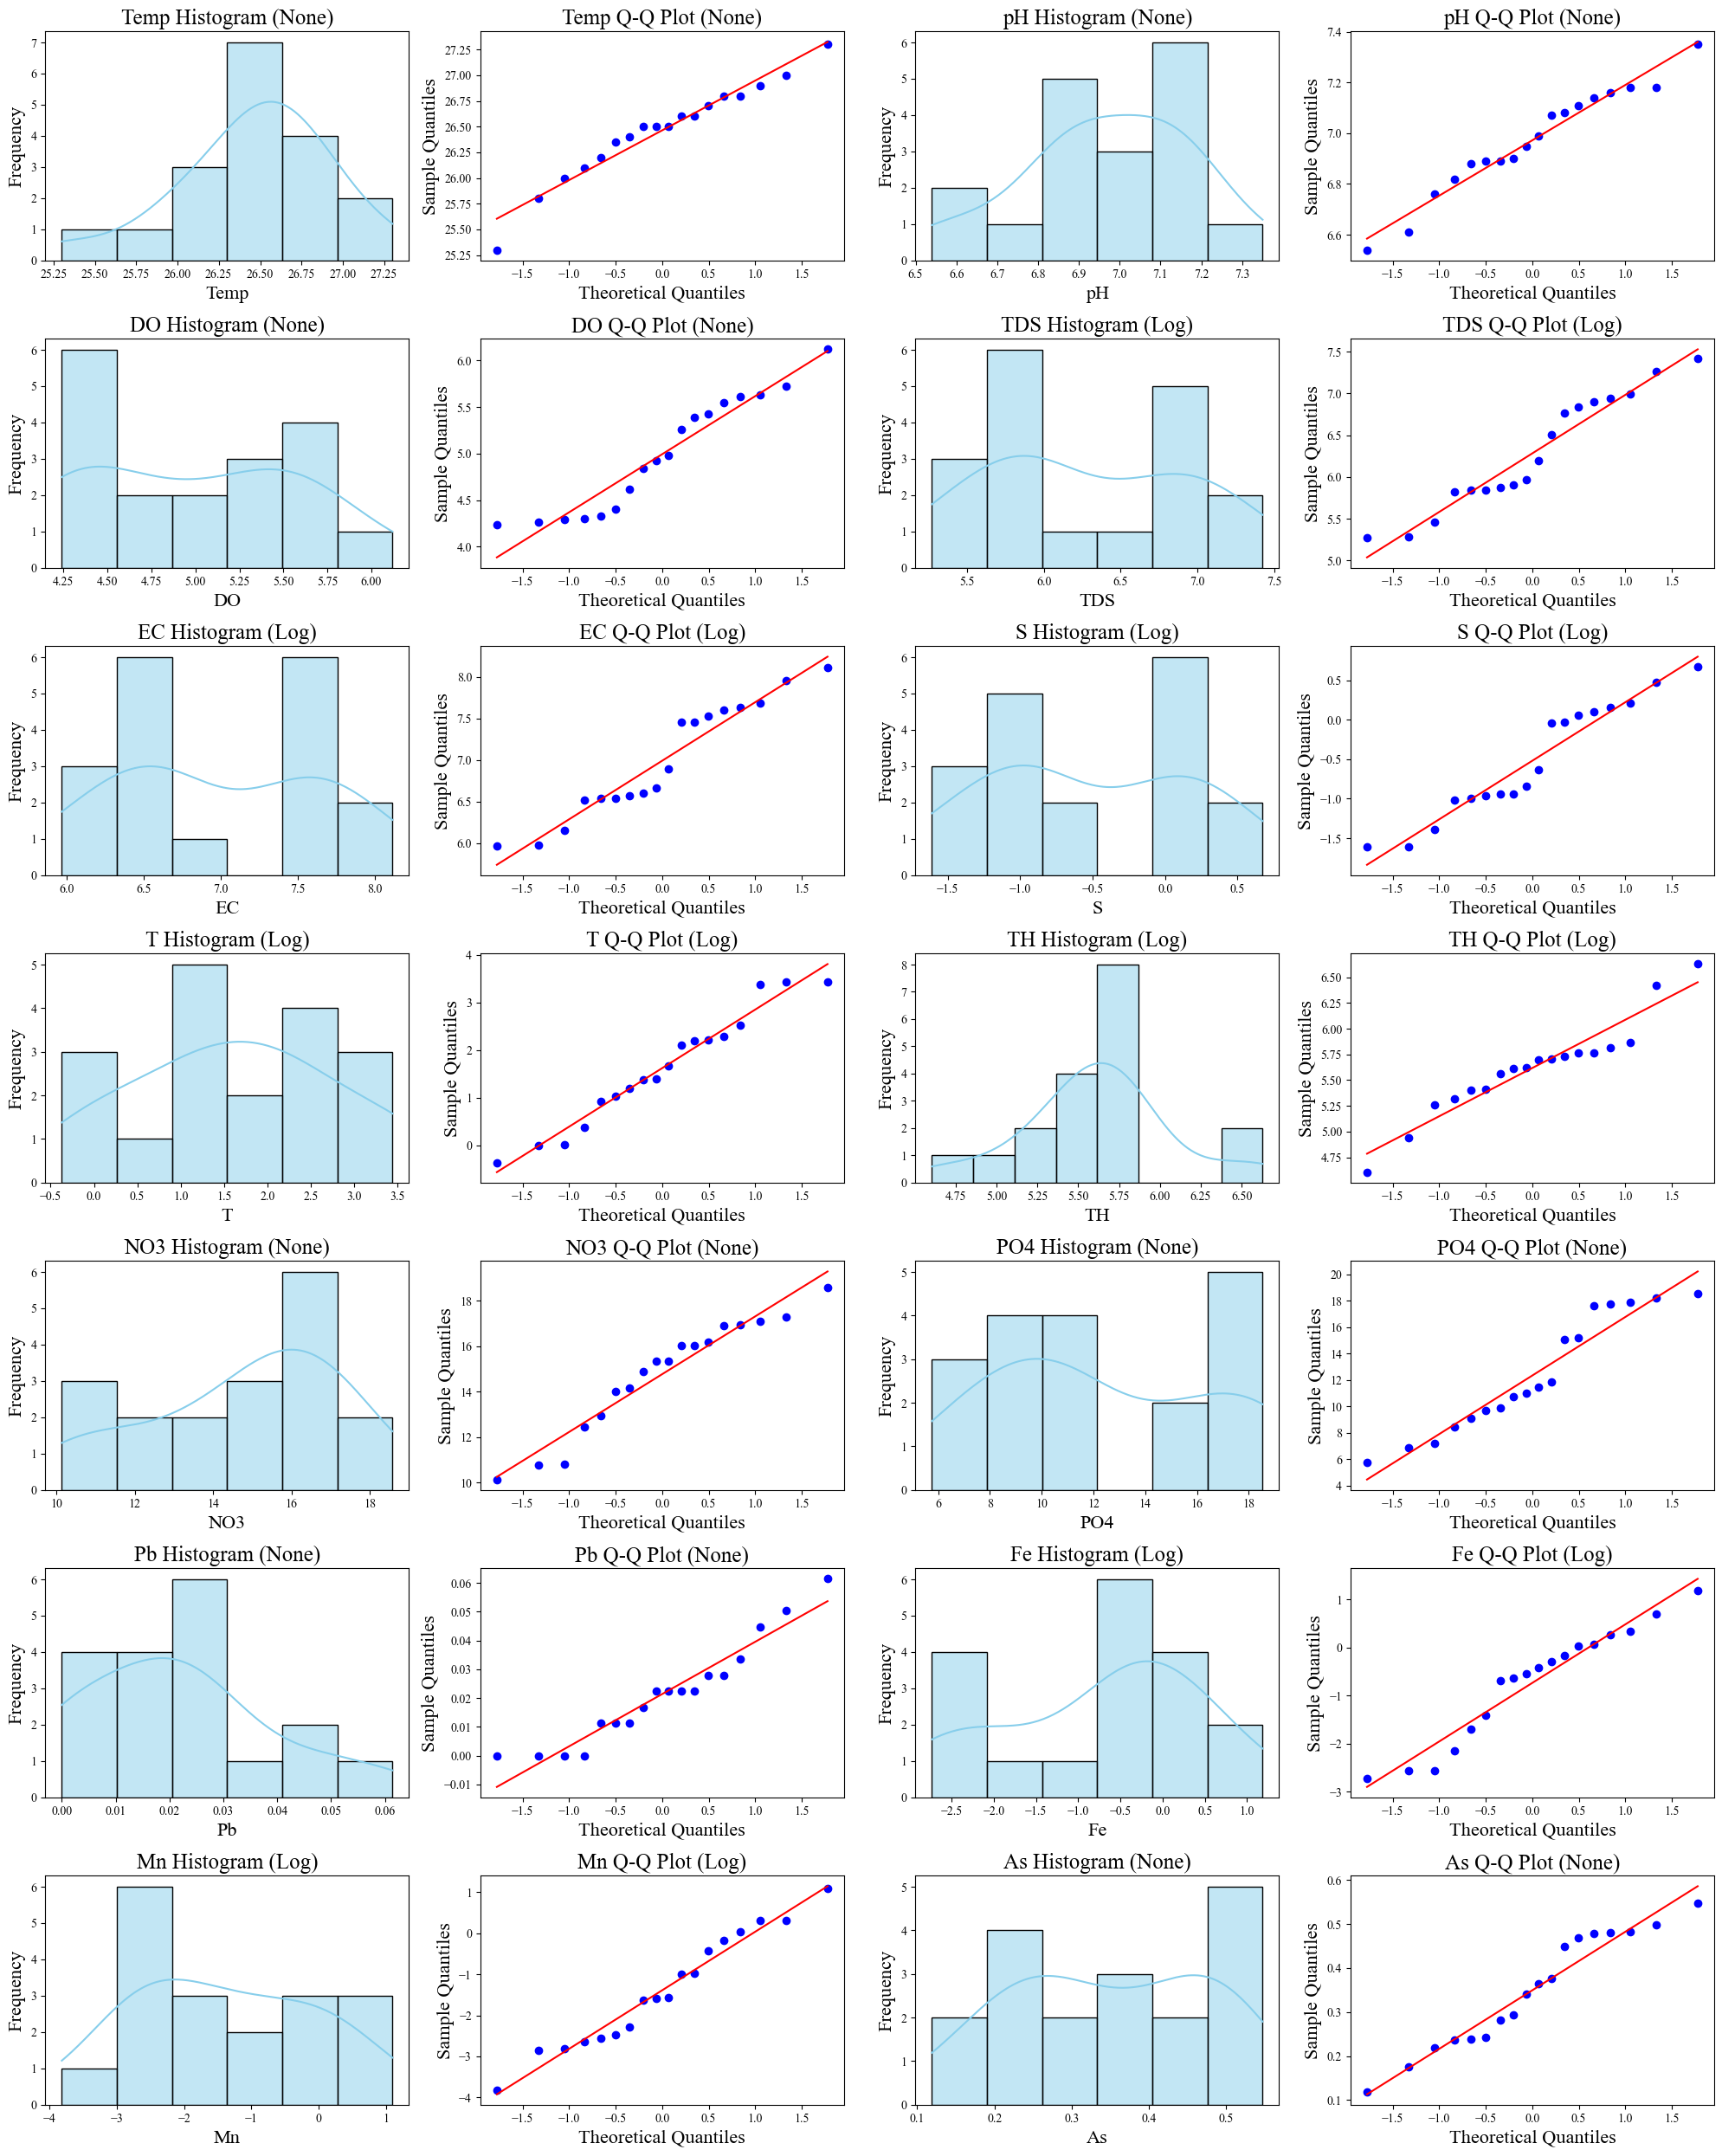

In [6]:
params = [col for col in df.columns if col != "Location"]

not_normal_params = ["TDS", "EC", "S", "T", "TH", "Fe", "Mn"]

def apply_transformation(series, param):
    if param in not_normal_params:
        return np.log(series + 1e-8)  # log transform
    else:
        return series  # keep raw

plt.rcParams["font.family"] = "Times New Roman"

fig, axes = plt.subplots(7, 4, figsize=(20, 25))

for i, param in enumerate(params):
    row = i // 2
    col_offset = (i % 2) * 2  # each param uses 2 subplots (hist + qq)
    
    data_transformed = apply_transformation(df[param].values, param)
    method = "Log" if param in not_normal_params else "None"
    sns.histplot(data_transformed, kde=True, ax=axes[row, col_offset],
                 color='skyblue', edgecolor='black')
    axes[row, col_offset].set_title(f'{param} Histogram ({method})', fontsize=18)
    axes[row, col_offset].set_xlabel(param, fontsize=16)
    axes[row, col_offset].set_ylabel("Frequency", fontsize=16)
    probplot(data_transformed, dist="norm", plot=axes[row, col_offset + 1])
    axes[row, col_offset + 1].set_title(f'{param} Q-Q Plot ({method})', fontsize=18)
    axes[row, col_offset + 1].set_xlabel("Theoretical Quantiles", fontsize=16)
    axes[row, col_offset + 1].set_ylabel("Sample Quantiles", fontsize=16)

for j in range(len(params), 14):
    row = j // 2
    col_offset = (j % 2) * 2
    axes[row, col_offset].axis('off')
    axes[row, col_offset + 1].axis('off')

plt.tight_layout()
plt.savefig("combined_params_plots_final.png", dpi=300)
plt.show()